# DPN for Binary Classification Classes (Expanded)

In [1]:
import json
import seaborn as sns
import warnings
import time
from pprint import pprint
import joblib
from tqdm import tqdm

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from CEval import CEval
import dice_ml
import shap
#. from module.dataload import DPN_data
#. from module.eda import EDA
#. from module.eda import EDAHelper

c:\Users\acbriza\anaconda3\envs\dpncf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#. 
import sys 
sys.path.append('..')  

from module.backends.backend_adapter import get_dice_components
from module.models.optimizers import grid_search_cv_binary
from module.dataload import DPN_data
from module.eda import EDA

In [3]:
warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

## Data Loading

In [5]:
D = DPN_data("../dataset/Sudoscan Working File with Stats.xlsx")
D.load(classification="binary")
D.load()

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1,64.0,1,7.0,1.0,15.00,0,0,0,0,0,1,1,1,1,9.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0,1
1,0,59.0,1,1.0,0.0,5.60,1,0,0,0,0,0,0,0,0,4.0,19.41,52.30,14.21,61.90,49.3,3.55,14.34,10.55,42.50,19.54,55.7,15.09,61.20,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0,0
2,0,64.0,1,11.0,1.0,7.50,1,0,0,0,0,1,1,1,1,5.0,0.00,0.00,0.00,0.00,35.9,4.35,1.83,1.29,54.40,0.00,0.0,0.00,0.00,36.2,4.70,2.40,1.92,54.7,65.0,14.0,79.0,1.0,50.0,33.0,1
3,0,53.0,1,10.0,1.0,7.60,1,0,1,0,0,1,0,0,0,8.0,7.86,46.70,7.07,42.50,40.4,4.30,6.08,4.20,51.00,8.98,48.7,8.08,42.70,40.0,4.25,7.81,6.18,50.9,43.0,10.0,49.0,5.0,57.0,33.0,1
4,1,57.0,0,5.0,1.0,14.40,0,0,0,0,0,1,0,1,1,1.0,4.19,41.90,3.70,38.20,38.5,4.50,8.89,6.88,48.30,5.36,45.5,4.42,39.50,38.3,4.00,10.29,8.82,49.9,54.0,3.0,63.0,0.0,54.0,36.0,1
5,0,20.0,1,2.0,1.0,7.80,0,0,0,0,0,0,0,1,0,0.0,26.55,47.40,14.42,49.60,45.4,3.75,17.17,11.36,49.40,32.17,46.3,16.06,44.10,42.2,3.35,21.26,15.37,50.3,67.0,4.0,80.0,4.0,99.0,0.0,0
6,0,69.0,0,0.0,0.0,8.00,1,0,1,0,0,0,1,0,0,1.0,11.40,51.70,17.16,54.50,44.7,3.20,13.69,10.06,46.40,12.56,48.7,13.61,53.40,48.4,3.70,13.51,8.37,46.6,74.0,1.0,77.0,6.0,49.0,33.0,0
7,0,60.0,0,2.0,0.0,5.80,1,0,0,0,0,1,0,0,0,5.0,19.46,49.60,7.46,49.60,42.3,3.30,13.74,10.44,47.00,19.50,46.2,9.84,40.10,43.8,3.40,13.55,10.87,46.9,63.0,4.0,65.0,11.0,54.0,29.0,0
8,1,62.0,0,0.0,1.0,14.36,0,0,0,0,0,1,1,1,0,3.0,8.36,45.10,0.00,0.00,36.4,3.75,9.20,6.53,56.10,7.58,44.6,0.00,0.00,35.7,3.95,9.42,7.25,57.2,72.0,2.0,61.0,19.0,56.0,31.0,1
9,0,44.0,1,17.0,0.0,7.01,0,0,0,0,0,1,1,1,1,10.0,1.13,46.90,0.00,0.00,36.6,5.10,4.22,2.52,56.60,1.26,42.4,0.00,0.00,35.6,4.75,4.02,2.09,55.4,19.0,10.0,84.0,1.0,64.0,18.0,1


Binary Classification Classes:  ['Negative', 'Possible', 'Probable'] vs 'Confirmed'


In [6]:
df = D.df
data_cols = df.drop(D.non_data_cols, axis=1, errors="ignore").columns
len(data_cols), data_cols

(40,
 Index(['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD',
        'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR',
        'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L',
        'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R',
        'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R',
        'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM',
        'NS', 'CAS'],
       dtype='object'))

### Data Inspection

In [7]:
X = df[data_cols]
y = df['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

### Set Global Variables

In [8]:
test_size = 0.25
verbosity = 1

### Full Features

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Classical ML models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [10]:
# Define Models
models = {
    "Naive": DummyClassifier(),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "SGDClassifier": make_pipeline(StandardScaler(), SGDClassifier(max_iter=1000, tol=1e-3)),

    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0),

    "kNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Naive Bayes": GaussianNB(),

    "Linear SVM": make_pipeline(StandardScaler(), SVC(kernel="linear", probability=True)),
    "RBF SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True)),
}

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, make_scorer
)

# Custom Youden Index scorer
def youden_index_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sensitivity + specificity - 1

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

youden_scorer = make_scorer(youden_index_score, greater_is_better=True)
specificity_scorer = make_scorer(specificity_score)

def benchmark_models(X, y, cv_splits=5, random_state=27):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "youden": youden_scorer,
        "specificity": specificity_scorer
    }

    results = []
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
        results.append({
            "Model": name,
            "Accuracy": np.mean(scores["test_accuracy"]),
            "Precision": np.mean(scores["test_precision"]),
            "Sensitivity": np.mean(scores["test_recall"]),
            "Specificity": np.mean(scores["test_specificity"]),
            "Youden Index": np.mean(scores["test_youden"]),
            "F1": np.mean(scores["test_f1"]),
            "ROC-AUC": np.mean(scores["test_roc_auc"]),
        })

    # sort by Youden Index instead of ROC-AUC
    return pd.DataFrame(results).sort_values(by="Youden Index", ascending=False).reset_index(drop=True)


----

## Iterative Group Feature Elimination

### All Features

In [46]:
dfall_results = benchmark_models(X, y)
dfall_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,Random Forest,0.958,0.970,0.969,0.933,0.903,0.969,0.978
1,CatBoost,0.947,0.962,0.962,0.917,0.878,0.962,0.976
2,LightGBM,0.942,0.948,0.969,0.883,0.853,0.958,0.973
3,Gradient Boosting,0.926,0.948,0.946,0.883,0.829,0.946,0.971
4,XGBoost,0.921,0.939,0.946,0.867,0.813,0.943,0.972
5,Extra Trees,0.916,0.932,0.946,0.850,0.796,0.939,0.979
6,Naive Bayes,0.821,0.962,0.769,0.933,0.703,0.852,0.926
7,RBF SVM,0.879,0.899,0.931,0.767,0.697,0.914,0.938
8,Decision Tree,0.863,0.901,0.900,0.783,0.683,0.900,0.842
9,kNN,0.879,0.886,0.946,0.733,0.679,0.914,0.938


In [47]:
# save to csv
dfall_results.to_csv(r"outputs\all_features\model_results.csv", index=None)

### No Collinear Features

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Example: df is your DataFrame with predictors
X2 = X.copy()

# Add constant term (intercept) for statsmodels
X2 = add_constant(X2)

# Compute VIF for each column
vif_data = pd.DataFrame()
vif_data["feature"] = X2.columns
vif_data["VIF"] = [variance_inflation_factor(X2.values, i) 
                   for i in range(X2.shape[1])]
high_vif = vif_data[vif_data["VIF"]>5]
print(high_vif)

      feature      VIF
0       const  433.829
17      SSA_L    6.858
18      SSC_L    6.793
20     SPSC_L   12.951
23  CMAPANK_L   30.508
24  CMAPKNE_L   30.224
26      SSA_R    5.531
27      SSC_R    5.805
28     SPSA_R    7.522
29     SPSC_R   11.552
32  CMAPANK_R   25.286
33  CMAPKNE_R   25.184


In [49]:
# drop these features which seem to be collinear
high_vif_features = ['SSA_L','SSC_L','SPSC_L','CMAPANK_L','CMAPKNE_L','SPSA_R', 'CMAPKNE_R']

In [50]:
Xnc = X.drop(columns=high_vif_features) #X no collinear
Xnc.shape, Xnc.head(2)

((190, 33),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0    1  64.0     1     7.0      1.0   15.0    0     0         0    0    0   
 1    0  59.0     1     1.0      0.0    5.6    1     0         0    0    0   
 
    DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  MNSI  SPSA_L  MCV_L  DL_L  FWAVE_L  \
 0       1        1        1       1   9.0    0.00    0.0  0.00      0.0   
 1       0        0        0       0   4.0   14.21   49.3  3.55     42.5   
 
    SSA_R  SSC_R  SPSC_R  MCV_R   DL_R  CMAPANK_R  FWAVE_R  FEET_MEAN_ESC  \
 0   0.00    0.0     0.0   20.7  10.35       0.03      0.0           12.0   
 1  19.54   55.7    61.2   48.3   3.30      13.29     43.3           39.0   
 
    FEET_PCT_ASYM  HAND_MEAN_ESC  HAND_PCT_ASYM    NS   CAS  
 0            0.0           33.0           13.0  42.0  34.0  
 1            5.0           38.0           28.0  50.0  39.0  )

In [51]:
dfnc_results = benchmark_models(Xnc, y)
dfnc_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,Random Forest,0.900,0.933,0.923,0.850,0.773,0.927,0.956
1,Gradient Boosting,0.889,0.927,0.915,0.833,0.749,0.918,0.965
2,XGBoost,0.895,0.919,0.931,0.817,0.747,0.923,0.944
3,CatBoost,0.895,0.920,0.931,0.817,0.747,0.924,0.963
4,Decision Tree,0.874,0.909,0.908,0.800,0.708,0.907,0.854
5,LightGBM,0.863,0.901,0.900,0.783,0.683,0.899,0.955
6,Extra Trees,0.858,0.874,0.931,0.700,0.631,0.900,0.948
7,Naive Bayes,0.779,0.924,0.738,0.867,0.605,0.813,0.897
8,Logistic Regression,0.821,0.863,0.885,0.683,0.568,0.872,0.885
9,LDA,0.826,0.856,0.900,0.667,0.567,0.877,0.869


In [52]:
dfnc_results.to_csv(r"outputs\nocollinear_features\model_results.csv", index=None)

 -----

### No NCS

In [53]:
Xnncs = X.drop(columns=D.ncs_cols) #X no nerve conduction studies
print(D.ncs_cols)
Xnncs.shape, Xnncs.head(2)

['SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R']


((190, 22),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0    1  64.0     1     7.0      1.0   15.0    0     0         0    0    0   
 1    0  59.0     1     1.0      0.0    5.6    1     0         0    0    0   
 
    DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  MNSI  FEET_MEAN_ESC  FEET_PCT_ASYM  \
 0       1        1        1       1   9.0           12.0            0.0   
 1       0        0        0       0   4.0           39.0            5.0   
 
    HAND_MEAN_ESC  HAND_PCT_ASYM    NS   CAS  
 0           33.0           13.0  42.0  34.0  
 1           38.0           28.0  50.0  39.0  )

In [54]:
dfnncs_results = benchmark_models(Xnncs, y)
dfnncs_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,Random Forest,0.795,0.820,0.900,0.567,0.467,0.857,0.829
1,XGBoost,0.784,0.817,0.885,0.567,0.451,0.849,0.785
2,Linear SVM,0.774,0.819,0.862,0.583,0.445,0.839,0.759
3,CatBoost,0.795,0.806,0.923,0.517,0.440,0.860,0.814
4,LDA,0.768,0.819,0.854,0.583,0.437,0.834,0.777
5,LightGBM,0.768,0.813,0.862,0.567,0.428,0.836,0.778
6,Naive Bayes,0.711,0.830,0.738,0.650,0.388,0.746,0.806
7,Logistic Regression,0.753,0.800,0.854,0.533,0.387,0.825,0.769
8,kNN,0.763,0.792,0.892,0.483,0.376,0.837,0.781
9,Extra Trees,0.753,0.792,0.869,0.500,0.369,0.828,0.813


In [55]:
dfnncs_results.to_csv(r"outputs\noNCS_features\model_results.csv", index=None)

 -----

### No Sudoscan Features

In [56]:
Xnsudo = X.drop(columns=D.sudo_cols) #X no nerve conduction studies
print(D.sudo_cols)
Xnsudo.shape, Xnsudo.head(2)

['FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'NS', 'CAS']


((190, 34),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0    1  64.0     1     7.0      1.0   15.0    0     0         0    0    0   
 1    0  59.0     1     1.0      0.0    5.6    1     0         0    0    0   
 
    DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  MNSI  SSA_L  SSC_L  SPSA_L  SPSC_L  \
 0       1        1        1       1   9.0   0.00    0.0    0.00     0.0   
 1       0        0        0       0   4.0  19.41   52.3   14.21    61.9   
 
    MCV_L  DL_L  CMAPANK_L  CMAPKNE_L  FWAVE_L  SSA_R  SSC_R  SPSA_R  SPSC_R  \
 0    0.0  0.00       0.00       0.00      0.0   0.00    0.0    0.00     0.0   
 1   49.3  3.55      14.34      10.55     42.5  19.54   55.7   15.09    61.2   
 
    MCV_R   DL_R  CMAPANK_R  CMAPKNE_R  FWAVE_R  
 0   20.7  10.35       0.03       0.02      0.0  
 1   48.3   3.30      13.29       9.48     43.3  )

In [57]:
dfnsudo_results = benchmark_models(Xnsudo, y)
dfnsudo_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,LightGBM,0.958,0.963,0.977,0.917,0.894,0.970,0.970
1,CatBoost,0.947,0.962,0.962,0.917,0.878,0.962,0.975
2,Random Forest,0.942,0.955,0.962,0.900,0.862,0.957,0.973
3,XGBoost,0.937,0.949,0.962,0.883,0.845,0.954,0.962
4,Gradient Boosting,0.926,0.940,0.954,0.867,0.821,0.947,0.971
5,Extra Trees,0.916,0.926,0.954,0.833,0.787,0.939,0.978
6,kNN,0.911,0.926,0.946,0.833,0.779,0.936,0.943
7,Linear SVM,0.895,0.923,0.923,0.833,0.756,0.923,0.929
8,RBF SVM,0.889,0.905,0.938,0.783,0.722,0.921,0.946
9,Naive Bayes,0.821,0.969,0.762,0.950,0.712,0.850,0.928


In [58]:
dfnsudo_results.to_csv(r"outputs\noSUDO_features\model_results.csv", index=None)

 -----

### No Neuro Features

In [59]:
Xnneuro = X.drop(columns=D.neuro_cols) #X no neuro columns
print(D.neuro_cols)
Xnneuro.shape, Xnneuro.head(2)

['DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR']


((190, 36),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0    1  64.0     1     7.0      1.0   15.0    0     0         0    0    0   
 1    0  59.0     1     1.0      0.0    5.6    1     0         0    0    0   
 
    MNSI  SSA_L  SSC_L  SPSA_L  SPSC_L  MCV_L  DL_L  CMAPANK_L  CMAPKNE_L  \
 0   9.0   0.00    0.0    0.00     0.0    0.0  0.00       0.00       0.00   
 1   4.0  19.41   52.3   14.21    61.9   49.3  3.55      14.34      10.55   
 
    FWAVE_L  SSA_R  SSC_R  SPSA_R  SPSC_R  MCV_R   DL_R  CMAPANK_R  CMAPKNE_R  \
 0      0.0   0.00    0.0    0.00     0.0   20.7  10.35       0.03       0.02   
 1     42.5  19.54   55.7   15.09    61.2   48.3   3.30      13.29       9.48   
 
    FWAVE_R  FEET_MEAN_ESC  FEET_PCT_ASYM  HAND_MEAN_ESC  HAND_PCT_ASYM    NS  \
 0      0.0           12.0            0.0           33.0           13.0  42.0   
 1     43.3           39.0            5.0           38.0           28.0  50.0   
 
     CAS  
 0  34.0  
 1  39.

In [60]:
dfnneuro_results = benchmark_models(Xnneuro, y)
dfnneuro_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,Random Forest,0.953,0.963,0.969,0.917,0.886,0.965,0.978
1,CatBoost,0.942,0.961,0.954,0.917,0.871,0.957,0.973
2,LightGBM,0.942,0.948,0.969,0.883,0.853,0.958,0.978
3,Extra Trees,0.932,0.947,0.954,0.883,0.837,0.950,0.978
4,Gradient Boosting,0.926,0.948,0.946,0.883,0.829,0.947,0.972
5,XGBoost,0.921,0.939,0.946,0.867,0.813,0.943,0.976
6,RBF SVM,0.905,0.907,0.962,0.783,0.745,0.933,0.947
7,Decision Tree,0.874,0.917,0.900,0.817,0.717,0.908,0.858
8,Naive Bayes,0.821,0.969,0.762,0.950,0.712,0.850,0.929
9,SGDClassifier,0.868,0.909,0.900,0.800,0.700,0.903,0.914


In [61]:
dfnneuro_results.to_csv(r"outputs\noNEURO_features\model_results.csv", index=None)

 -----

### No Commorbidity Features

In [62]:
Xncom = X.drop(columns=D.comorbidity_cols) #X no neuro columns
print(D.comorbidity_cols)
Xncom.shape, Xncom.head(2)

['HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS']


((190, 35),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  \
 0    1  64.0     1     7.0      1.0   15.0       1        1        1       1   
 1    0  59.0     1     1.0      0.0    5.6       0        0        0       0   
 
    MNSI  SSA_L  SSC_L  SPSA_L  SPSC_L  MCV_L  DL_L  CMAPANK_L  CMAPKNE_L  \
 0   9.0   0.00    0.0    0.00     0.0    0.0  0.00       0.00       0.00   
 1   4.0  19.41   52.3   14.21    61.9   49.3  3.55      14.34      10.55   
 
    FWAVE_L  SSA_R  SSC_R  SPSA_R  SPSC_R  MCV_R   DL_R  CMAPANK_R  CMAPKNE_R  \
 0      0.0   0.00    0.0    0.00     0.0   20.7  10.35       0.03       0.02   
 1     42.5  19.54   55.7   15.09    61.2   48.3   3.30      13.29       9.48   
 
    FWAVE_R  FEET_MEAN_ESC  FEET_PCT_ASYM  HAND_MEAN_ESC  HAND_PCT_ASYM    NS  \
 0      0.0           12.0            0.0           33.0           13.0  42.0   
 1     43.3           39.0            5.0           38.0           28.0  50.0   
 
     CAS  
 0  34.0 

In [63]:
dfncom_results = benchmark_models(Xncom, y)
dfncom_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,Random Forest,0.953,0.970,0.962,0.933,0.895,0.965,0.979
1,CatBoost,0.947,0.969,0.954,0.933,0.887,0.961,0.976
2,Extra Trees,0.932,0.947,0.954,0.883,0.837,0.950,0.980
3,Gradient Boosting,0.932,0.948,0.954,0.883,0.837,0.950,0.973
4,LightGBM,0.937,0.941,0.969,0.867,0.836,0.954,0.978
5,XGBoost,0.921,0.939,0.946,0.867,0.813,0.943,0.972
6,Naive Bayes,0.842,0.973,0.792,0.950,0.742,0.873,0.952
7,Linear SVM,0.884,0.911,0.923,0.800,0.723,0.916,0.929
8,Logistic Regression,0.879,0.903,0.923,0.783,0.706,0.912,0.929
9,RBF SVM,0.884,0.899,0.938,0.767,0.705,0.918,0.947


In [64]:
dfncom_results.to_csv(r"outputs\noCOM_features\model_results.csv", index=None)

 -----

### No MNSI Feature

In [65]:
Xnmnsi = X.drop(columns=D.mnsi_col) #X no neuro columns
print(D.mnsi_col)
Xnmnsi.shape, Xnmnsi.head(2)

['MNSI']


((190, 39),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0    1  64.0     1     7.0      1.0   15.0    0     0         0    0    0   
 1    0  59.0     1     1.0      0.0    5.6    1     0         0    0    0   
 
    DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  SSA_L  SSC_L  SPSA_L  SPSC_L  MCV_L  \
 0       1        1        1       1   0.00    0.0    0.00     0.0    0.0   
 1       0        0        0       0  19.41   52.3   14.21    61.9   49.3   
 
    DL_L  CMAPANK_L  CMAPKNE_L  FWAVE_L  SSA_R  SSC_R  SPSA_R  SPSC_R  MCV_R  \
 0  0.00       0.00       0.00      0.0   0.00    0.0    0.00     0.0   20.7   
 1  3.55      14.34      10.55     42.5  19.54   55.7   15.09    61.2   48.3   
 
     DL_R  CMAPANK_R  CMAPKNE_R  FWAVE_R  FEET_MEAN_ESC  FEET_PCT_ASYM  \
 0  10.35       0.03       0.02      0.0           12.0            0.0   
 1   3.30      13.29       9.48     43.3           39.0            5.0   
 
    HAND_MEAN_ESC  HAND_PCT_ASYM    NS   CAS  
 0    

In [66]:
dfnmnsi_results = benchmark_models(Xnmnsi, y)
dfnmnsi_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,Random Forest,0.958,0.970,0.969,0.933,0.903,0.969,0.976
1,CatBoost,0.942,0.961,0.954,0.917,0.871,0.957,0.974
2,Extra Trees,0.926,0.940,0.954,0.867,0.821,0.947,0.979
3,Gradient Boosting,0.926,0.941,0.954,0.867,0.821,0.947,0.971
4,XGBoost,0.926,0.940,0.954,0.867,0.821,0.947,0.974
5,LightGBM,0.926,0.940,0.954,0.867,0.821,0.946,0.972
6,Decision Tree,0.889,0.911,0.931,0.800,0.731,0.920,0.865
7,Naive Bayes,0.826,0.970,0.769,0.950,0.719,0.856,0.927
8,kNN,0.884,0.897,0.938,0.767,0.705,0.917,0.932
9,Logistic Regression,0.863,0.889,0.915,0.750,0.665,0.901,0.910


In [67]:
dfnmnsi_results.to_csv(r"outputs\noMNSI_feature\model_results.csv", index=None)

 -----

### No Profile Feature

In [68]:
Xnprof = X.drop(columns=D.profile_cols) #X no neuro columns
print(D.profile_cols)
Xnprof.shape, Xnprof.head(2)

['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C']


((190, 34),
    HPN  PAOD  DSLPDMIA  CKD  GBS  DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  MNSI  \
 0    0     0         0    0    0       1        1        1       1   9.0   
 1    1     0         0    0    0       0        0        0       0   4.0   
 
    SSA_L  SSC_L  SPSA_L  SPSC_L  MCV_L  DL_L  CMAPANK_L  CMAPKNE_L  FWAVE_L  \
 0   0.00    0.0    0.00     0.0    0.0  0.00       0.00       0.00      0.0   
 1  19.41   52.3   14.21    61.9   49.3  3.55      14.34      10.55     42.5   
 
    SSA_R  SSC_R  SPSA_R  SPSC_R  MCV_R   DL_R  CMAPANK_R  CMAPKNE_R  FWAVE_R  \
 0   0.00    0.0    0.00     0.0   20.7  10.35       0.03       0.02      0.0   
 1  19.54   55.7   15.09    61.2   48.3   3.30      13.29       9.48     43.3   
 
    FEET_MEAN_ESC  FEET_PCT_ASYM  HAND_MEAN_ESC  HAND_PCT_ASYM    NS   CAS  
 0           12.0            0.0           33.0           13.0  42.0  34.0  
 1           39.0            5.0           38.0           28.0  50.0  39.0  )

In [69]:
dfnprof_results = benchmark_models(Xnprof, y)
dfnprof_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,CatBoost,0.947,0.969,0.954,0.933,0.887,0.961,0.967
1,Random Forest,0.937,0.948,0.962,0.883,0.845,0.954,0.970
2,LightGBM,0.932,0.947,0.954,0.883,0.837,0.950,0.960
3,Gradient Boosting,0.921,0.948,0.938,0.883,0.822,0.942,0.965
4,XGBoost,0.921,0.947,0.938,0.883,0.822,0.942,0.962
5,Extra Trees,0.921,0.939,0.946,0.867,0.813,0.943,0.966
6,Naive Bayes,0.826,0.970,0.769,0.950,0.719,0.856,0.924
7,Linear SVM,0.863,0.907,0.892,0.800,0.692,0.899,0.917
8,Logistic Regression,0.868,0.902,0.908,0.783,0.691,0.904,0.909
9,RBF SVM,0.874,0.894,0.931,0.750,0.681,0.911,0.933


In [70]:
dfnprof_results.to_csv(r"outputs\noPROF_features\model_results.csv", index=None)

 -----

### Summary of Iterative Group Feature Elimination

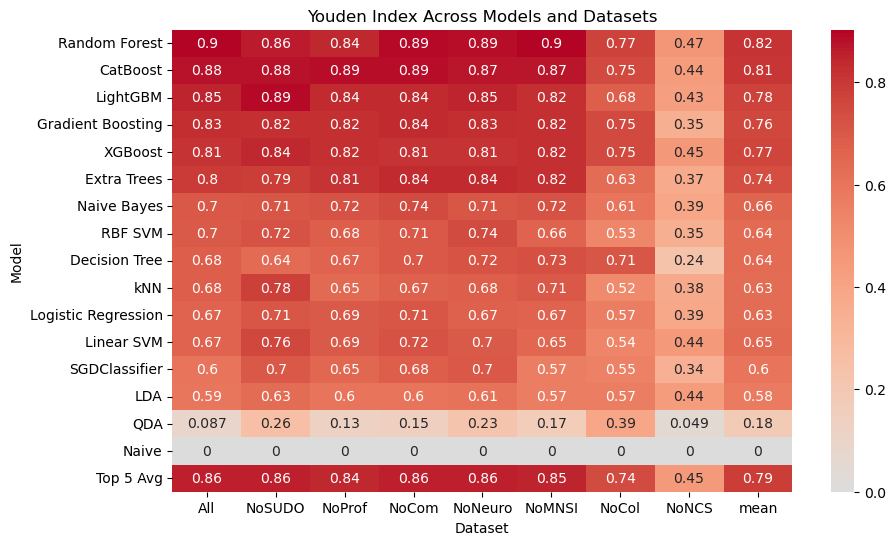

In [71]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# Suppose you have several results DataFrames
# e.g., results_df1, results_df2, results_df3

dataframes = {
    "All": dfall_results,
    "NoSUDO": dfnsudo_results,
    "NoProf": dfnprof_results,
    "NoCom": dfncom_results,
    "NoNeuro": dfnneuro_results,
    "NoMNSI": dfnmnsi_results,
    "NoCol": dfnc_results,
    "NoNCS": dfnncs_results,
}

# Collect the 'Youden' column from each dataframe
youden_table = pd.DataFrame()

for name, df in dataframes.items():
    youden_table[name] = df.set_index("Model")["Youden Index"]
k=5
topk_avg = youden_table.apply(lambda col: col.nlargest(k).mean())
youden_table.loc[f"Top {k} Avg"] = topk_avg

youden_table['mean'] = youden_table.mean(axis=1)

# Reorder rows if needed
# youden_table = youden_table.reindex(sorted(youden_table.index))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(youden_table, annot=True, cmap="coolwarm", center=0)
plt.title("Youden Index Across Models and Datasets")
plt.ylabel("Model")
plt.xlabel("Dataset")
plt.show()


## NCS Only

In [72]:
Xncs = X[D.ncs_cols] #X no neuro columns
print(D.ncs_cols)
Xncs.shape, Xncs.head(2)

['SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R']


((190, 18),
    SSA_L  SSC_L  SPSA_L  SPSC_L  MCV_L  DL_L  CMAPANK_L  CMAPKNE_L  FWAVE_L  \
 0   0.00    0.0    0.00     0.0    0.0  0.00       0.00       0.00      0.0   
 1  19.41   52.3   14.21    61.9   49.3  3.55      14.34      10.55     42.5   
 
    SSA_R  SSC_R  SPSA_R  SPSC_R  MCV_R   DL_R  CMAPANK_R  CMAPKNE_R  FWAVE_R  
 0   0.00    0.0    0.00     0.0   20.7  10.35       0.03       0.02      0.0  
 1  19.54   55.7   15.09    61.2   48.3   3.30      13.29       9.48     43.3  )

In [73]:
dfncs_results = benchmark_models(Xncs, y)
dfncs_results

,Model,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,Extra Trees,0.942,0.969,0.946,0.933,0.879,0.957,0.954
1,RBF SVM,0.937,0.961,0.946,0.917,0.863,0.954,0.931
2,Random Forest,0.942,0.956,0.962,0.900,0.862,0.958,0.956
3,CatBoost,0.937,0.954,0.954,0.900,0.854,0.954,0.950
4,Linear SVM,0.921,0.953,0.931,0.900,0.831,0.942,0.934
5,Logistic Regression,0.921,0.954,0.931,0.900,0.831,0.941,0.936
6,LightGBM,0.926,0.946,0.946,0.883,0.829,0.946,0.935
7,kNN,0.921,0.946,0.938,0.883,0.822,0.942,0.935
8,Gradient Boosting,0.926,0.941,0.954,0.867,0.821,0.947,0.937
9,XGBoost,0.916,0.940,0.938,0.867,0.805,0.938,0.918


In [74]:
dfncs_results.to_csv(r"outputs\NCS_features\model_results.csv", index=None)

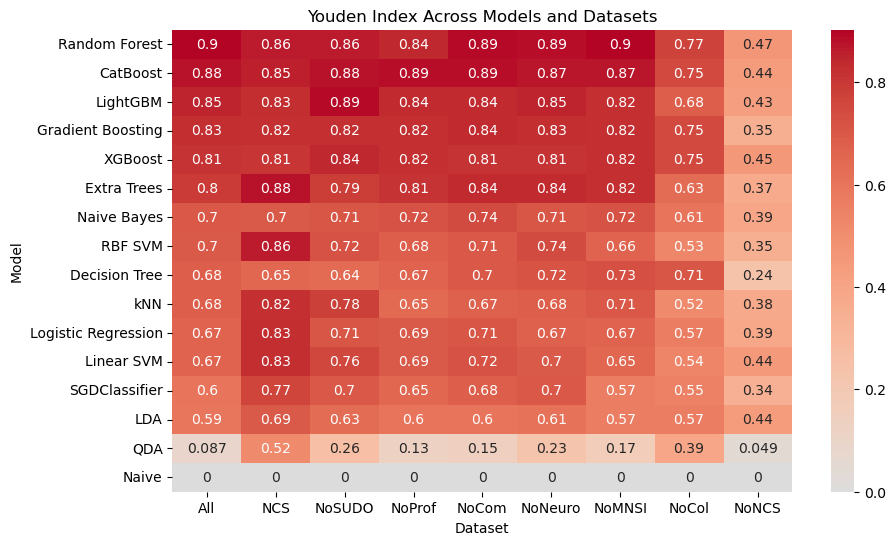

In [75]:
dataframes = {
    "All": dfall_results,
    "NCS": dfncs_results,
    "NoSUDO": dfnsudo_results,
    "NoProf": dfnprof_results,
    "NoCom": dfncom_results,
    "NoNeuro": dfnneuro_results,
    "NoMNSI": dfnmnsi_results,
    "NoCol": dfnc_results,
    "NoNCS": dfnncs_results,
}

# Collect the 'Youden' column from each dataframe
youden_table = pd.DataFrame()

for name, df in dataframes.items():
    youden_table[name] = df.set_index("Model")["Youden Index"]

# Reorder rows if needed
# youden_table = youden_table.reindex(sorted(youden_table.index))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(youden_table, annot=True, cmap="coolwarm", center=0)
plt.title("Youden Index Across Models and Datasets")
plt.ylabel("Model")
plt.xlabel("Dataset")
plt.savefig('outputs/model_cv5_summary.png')
plt.show()


 -----

## Bayesian Optmization of Best Binary Classifier (RF)

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# Define the model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Define the hyperparameter search space
param_space = {
    "n_estimators": Integer(50, 500),
    "max_depth": Integer(2, 30),
    "min_samples_split": Integer(2, 10),
    "min_samples_leaf": Integer(1, 10),
    "criterion": Categorical(["gini", "entropy"]),
    "max_features": Categorical(["sqrt", "log2", 0.8]),
    "bootstrap": Categorical([True, False]),
    "class_weight": Categorical([None, "balanced", "balanced_subsample"])
}

# Bayesian Optimization with cross-validation
opt = BayesSearchCV(
    estimator=rf,
    search_spaces=param_space,
    n_iter=100,                # number of parameter settings to try
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=27),
    scoring="roc_auc",        # or "youden", "f1", etc.
    n_jobs=-1,
    random_state=42,
    verbose=0
)

opt.fit(X, y)

print("Best parameters:", opt.best_params_)
print("Best ROC-AUC:", opt.best_score_)


In [ ]:
best_model = opt.best_estimator_

 -----

## Model Evaluation Preparation

#### Train Test Split

In [17]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=0, stratify=y)

#### Evaluate the Model

In [18]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "Specificity": specificity_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        "Youden Index": youden_index_score(y_test, y_pred)
    }
    return pd.Series(metrics)

## Model Evaluation

In [19]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)
y_proba = best_model.predict_proba(X_val)[:, 1]
results = evaluate_model(best_model, X_val, y_val)
print(results)

NameError: name 'best_model' is not defined

#### Saving the Optimized Model

In [ ]:
def save_optimized_results(name, best_params, best_score, optimized_model, optimized_model_metrics):
    model_results = { 
        "name" : name,
        "best_params": best_params, 
        "best_score": best_score, 
        "optimized_model": optimized_model, 
        "optimized_model_metrics": optimized_model_metrics
    }
    joblib.dump(model_results, rf"outputs\all_features\{name}.pkl")

In [ ]:
save_optimized_results("random_forest", opt.best_params_, opt.best_score_, best_model, results)

## Post Optimization Analysis from Saved File

#### Load variables from pickle file

In [15]:
rf_optimized_results = joblib.load(rf"outputs\all_features\random_forest.pkl")

model_name = rf_optimized_results["name"]
best_params = rf_optimized_results["best_params"]
best_score = rf_optimized_results["best_score"]  
optimized_model = rf_optimized_results["optimized_model"] 
optimized_model_metrics = rf_optimized_results["optimized_model_metrics"]

optimized_model_metrics

Accuracy                0.938
Precision               0.969
Recall (Sensitivity)    0.939
Specificity             0.933
F1                      0.954
ROC-AUC                 0.992
Youden Index            0.873
dtype: float64

In [20]:
# optimized_model.fit(X_train, y_train) # no longer needed
y_pred = optimized_model.predict(X_val)
y_proba = optimized_model.predict_proba(X_val)[:, 1]
results = evaluate_model(optimized_model, X_val, y_val)
print(results)

Accuracy                0.938
Precision               0.969
Recall (Sensitivity)    0.939
Specificity             0.933
F1                      0.954
ROC-AUC                 0.992
Youden Index            0.873
dtype: float64


#### Define Features Group Color Map

In [ ]:
import matplotlib.patches as mpatches

palette = {
    'Teal': '#8DD3C7', 
    'Yellow': '#FFFFB3', 
    'Lavender': '#BEBADA', 
    'Coral': '#FB8072', 
    'Blue': '#80B1D3', 
    'Orange': '#FDB462', 
    'Green': '#B3DE69', 
    'Pink': '#FCCDE5', 
    'Purple': '#BC80BD', 
    'Gray': '#D9D9D9', 
    'Red': '#E41A1C' 
}

COLOR_GROUP_MAP = {
    'Nerve Conduction Studies': palette['Blue'],
    'Sudoscan': palette['Orange'],
    'Profile': palette['Teal'],
    'Comorbidities': palette['Red'],
    'Neurology Examination': palette['Pink'],
    'MNSI': palette['Green'],
    # 'Others': palette['Gray']
}

def get_colors(labels):
    # D is assumed to be available in the scope (e.g., imported module or class instance)
    return [
        COLOR_GROUP_MAP['Nerve Conduction Studies']  if label in D.ncs_cols else 
        COLOR_GROUP_MAP['Sudoscan'] if label in D.sudo_cols else 
        COLOR_GROUP_MAP['Profile'] if label in D.profile_cols else 
        COLOR_GROUP_MAP['Comorbidities'] if label in D.comorbidity_cols else # Assuming 'Red' is the intended color
        COLOR_GROUP_MAP['Neurology Examination'] if label in D.neuro_cols else 
        COLOR_GROUP_MAP['MNSI'] if label in D.mnsi_col else 
        palette['Gray']
        for label in labels
    ]

#### Feature Importance

In [21]:
importances = optimized_model.feature_importances_
feature_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feature_importances_trimmed = feature_importances[feature_importances>0.001]
feature_importances_trimmed[:5]

CMAPKNE_L    0.163
SSA_R        0.152
CMAPKNE_R    0.119
SSA_L        0.106
CMAPANK_L    0.058
dtype: float64

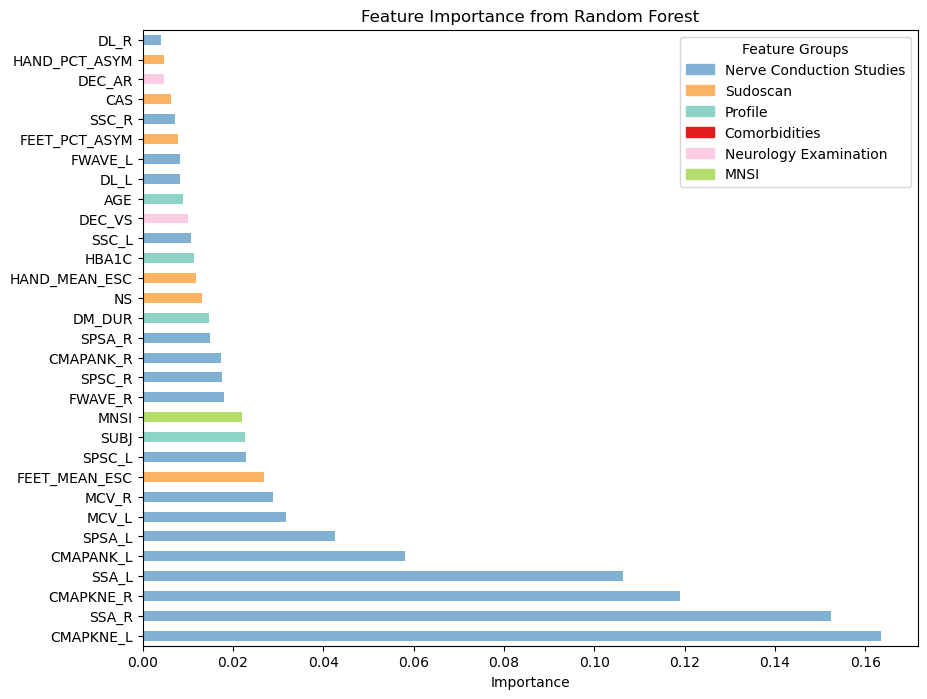

In [78]:
plt.figure(figsize=(10,8))
ax = feature_importances_trimmed.plot(
    kind='barh',
    color = get_colors(feature_importances_trimmed.index.to_list())
)

plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")

# --- Legend Addition ---
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the legend to the plot
ax.legend(
    handles=legend_handles, 
    title="Feature Groups", 
    loc='best' # Adjust location as needed (e.g., 'best', 'outside')
)
plt.savefig(r'outputs\figures\'rf_features_importances.png')
plt.show()

#### ROC Curve

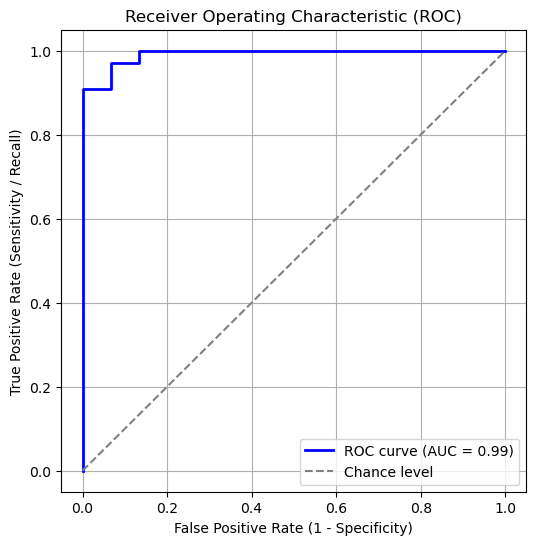

In [37]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance level')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
plt.savefig("outputs/figures/rf_roc.png") 

### DCA

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def decision_curve_analysis(model, X, y, thresholds=None, label="Model"):
    """
    Perform Decision Curve Analysis (DCA) for a trained classifier.

    Parameters:
    -----------
    model : sklearn-like estimator
        Must have a predict_proba method.
    X : array-like
        Feature matrix (test set).
    y : array-like
        True binary labels.
    thresholds : array-like, optional
        List or array of thresholds to evaluate. Defaults to np.linspace(0.01, 0.99, 50).
    label : str, optional
        Label for the model curve.

    Returns:
    --------
    thresholds : np.array
        Threshold probabilities.
    net_benefits : list
        Net benefit values for the model.
    """

    # Default thresholds
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 50)

    # Get predicted probabilities
    y_pred_prob = model.predict_proba(X)[:, 1]

    N = len(y)
    net_benefits = []

    for pt in thresholds:
        y_pred = (y_pred_prob >= pt).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        net_benefit = (tp / N) - (fp / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)

    # Plotting
    plt.plot(thresholds, net_benefits, label=label, linewidth=2)
    plt.plot(thresholds, [0]*len(thresholds), linestyle="--", label="Treat None")
    plt.plot(thresholds, thresholds, linestyle="--", label="Treat All")  # Simplified version

    plt.xlabel("Threshold Probability")
    plt.ylabel("Net Benefit")
    plt.title("Decision Curve Analysis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    return thresholds, net_benefits


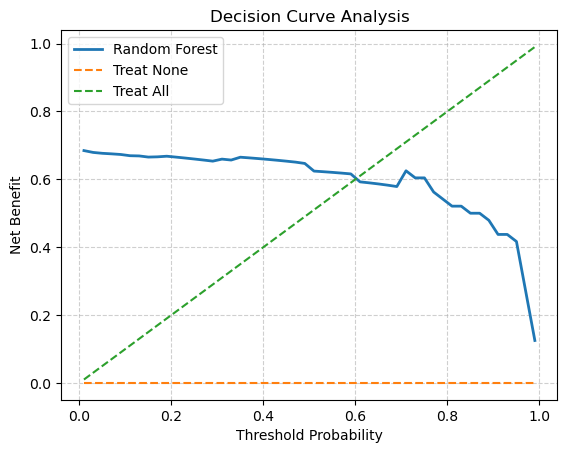

In [18]:
thresholds, nb = decision_curve_analysis(optimized_model, X_val, y_val, label="Random Forest")

In [19]:
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
youden_index = tpr - fpr
best_threshold = thresholds[youden_index.argmax()]
print("Best threshold:", best_threshold)

Best threshold: 0.7288739145225853


### Evaluate Best Threshold for Youden Index

In [20]:
def evaluate_model_thresholded(model, X_test, y_test, threshold):
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    y_pred = (y_proba >= threshold).astype(int)
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "Specificity": specificity_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        "Youden Index": youden_index_score(y_test, y_pred)
    }
    return pd.Series(metrics)

thresholds = np.arange(0.1, 0.85, 0.05)
youdens = [evaluate_model_thresholded(optimized_model, X_val, y_val, k)['Youden Index'] for k in thresholds]

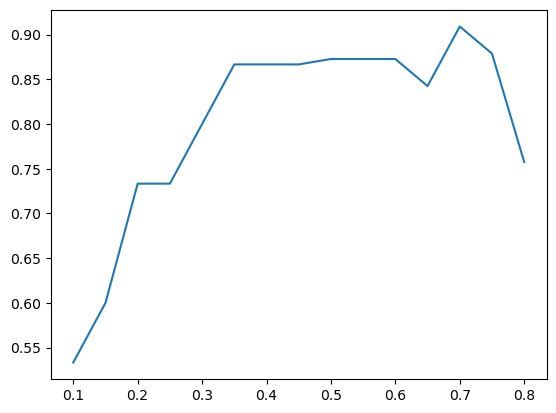

In [21]:
plt.plot(thresholds, youdens)
plt.show()

## SHAP Analysis

In [79]:
# Define a simple predict function for the current model
# This closure ensures 'model' refers to the correct model in each iteration
def current_model_predict(X):
    # For classifiers, .predict_proba is often preferred for SHAP for better interpretability
    # especially for multi-class, but .predict is also valid.
    # We'll use .predict here as per your original request, but it's good to note.
    return optimized_model.predict_proba(X)[:, 1] #.
    #. return optimized_model.predict(X) 

# Use a masker: your input DataFrame
#. Don't use a masker so we preserve correlations
#. masker = shap.maskers.Independent(X_val)

# Create explainer with custom predict function
# Specify the masker for consistency
#. explainer = shap.Explainer(current_model_predict, masker=masker)

#. use x_val directly
explainer = shap.Explainer(current_model_predict, X_val) 

# Compute SHAP values
shap_values = explainer(X_val)

PermutationExplainer explainer: 49it [00:15,  1.99it/s]                        


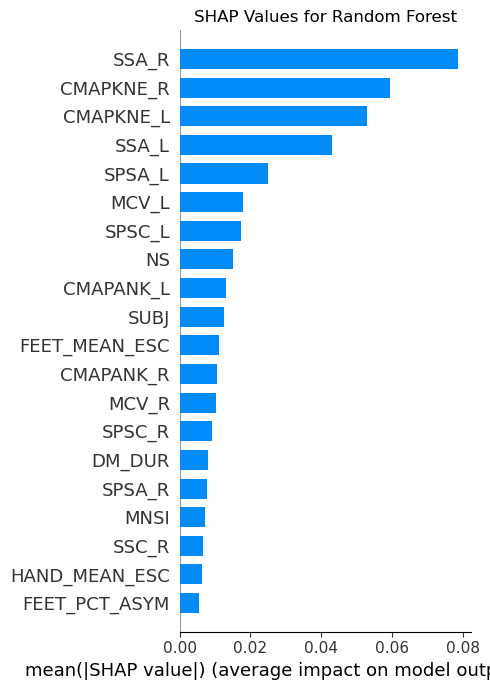

In [23]:
# Plot the summary plot for the current model
# show=False prevents immediate display, allowing title to be set
plt.figure(figsize=(5,7))
shap.summary_plot(shap_values, X_val, show=False, plot_type="bar", plot_size=None)
plt.title(f"SHAP Values for {model_name.replace('_', ' ').title()}")
plt.tight_layout() # Adjust layout to prevent title overlap
plt.show() # Display the plot for the current model

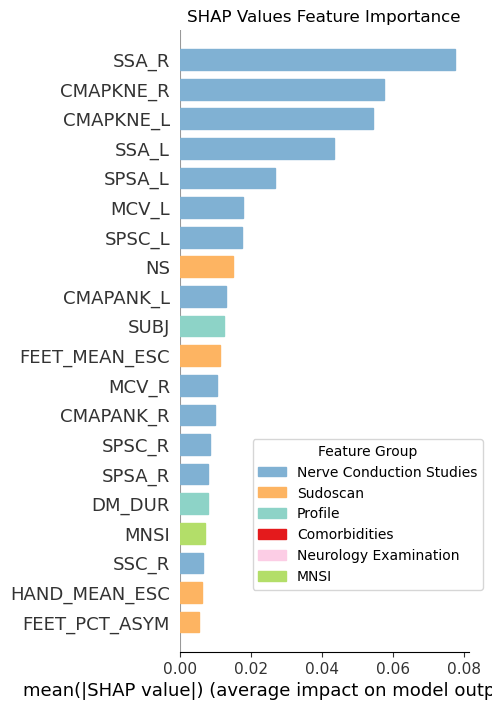

In [90]:

# Assuming 'D' is an available object with the feature lists (e.g., D.ncs_cols)
# Assuming 'shap_values' and 'X_val' are defined.

plt.figure(figsize=(5, 7))

# 3.1 Generate the SHAP summary plot (bar type)
# We set show=False to prevent Matplotlib from displaying it immediately
shap.summary_plot(shap_values, X_val, show=False, plot_type="bar", plot_size=None)

# 3.2 Get the current Axes object (which contains the plot)
# This is usually the first (and only) Axes created by the shap plot.
ax = plt.gca()

# 3.3 Identify the features and assign colors
# The SHAP bar plot automatically orders features by importance (the Y-axis labels)
feature_names = [label.get_text() for label in ax.get_yticklabels()]
bar_colors = get_colors(feature_names)

# 3.4 Manually re-color the bars 
# The bars are the first container of rectangles in the axes.
# They are typically stored in ax.containers[0]
for bar, color in zip(ax.containers[0].patches, bar_colors):
    bar.set_color(color)

# 3.5 Add Custom Legend
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Set the title first (from your original prompt)
plt.title("SHAP Values Feature Importance")

# Add the legend to the plot
ax.legend(
    handles=legend_handles, 
    title="Feature Group", 
    loc='lower right', # Adjust location as needed
    bbox_to_anchor=(1.05, 0.1), # Place outside the plot area, for example
    borderaxespad=0.
)

# 3.6 Display the plot
plt.show()


## Global Counterfactual Analysis

### Actionable (Flip Both Ways), Full dataset

#### Preparation

In [22]:
X.shape, y.shape

((190, 40), (190,))

In [23]:
dfXy = pd.concat([X, y], axis=1)
dfXy.shape

(190, 41)

In [24]:
d = dice_ml.Data(dataframe=dfXy, continuous_features=dfXy.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=optimized_model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")

#### Generate 3 Sample CFs for Patient 0

In [25]:
pid = 0
query_instance = X[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 


generating counterfactuals for the random_forest model


100%|██████████| 1/1 [00:00<00:00,  2.08it/s]

Query instance (original outcome : 1)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,64.0,1.0,7.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,25.0,-,1.0,0.0,11.0,-,-,-,-,-,0.0,-,-,-,5.0,12.1,47.5,6.8,42.0,40.8,3.5,13.71,7.21,52.6,13.3,43.2,6.0,42.7,40.3,3.8,11.1,6.93,52.7,37.0,5.0,46.0,14.0,76.0,7.0,0.0
0,0.0,59.0,-,4.0,0.0,10.5,-,-,-,-,-,-,-,-,0.0,3.0,10.1,51.5,4.4,59.6,-,3.25,-,10.13,45.1,13.1,54.5,5.9,-,47.6,0.0,17.12,10.07,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0
0,0.0,59.0,-,4.0,0.0,10.5,-,-,-,-,-,-,-,-,-,3.0,10.1,51.5,4.4,59.6,47.4,3.25,16.2,10.13,45.1,13.1,54.5,5.9,52.6,47.6,3.6,17.12,10.07,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0


#### Global Importance

In [36]:
cobj = exp.global_feature_importance(X, total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

100%|██████████| 190/190 [27:04<00:00,  8.55s/it]


{'CMAPKNE_L': 0.9947173798203909, 'CMAPANK_R': 0.9947173798203909, 'CMAPKNE_R': 0.9947173798203909, 'CMAPANK_L': 0.9931325937665082, 'SSA_R': 0.9899630216587427, 'SSA_L': 0.98837823560486, 'FWAVE_R': 0.9867934495509773, 'HBA1C': 0.9852086634970946, 'MCV_R': 0.9852086634970946, 'FWAVE_L': 0.9836238774432118, 'FEET_MEAN_ESC': 0.9825673534072901, 'HAND_MEAN_ESC': 0.9809825673534073, 'MCV_L': 0.9799260433174855, 'SPSA_L': 0.9783412572636028, 'NS': 0.9751716851558373, 'SSC_R': 0.9741151611199155, 'SPSC_L': 0.971473851030111, 'SPSA_R': 0.9688325409403064, 'DL_R': 0.9688325409403064, 'AGE': 0.9672477548864237, 'SSC_L': 0.9672477548864237, 'SPSC_R': 0.965662968832541, 'DL_L': 0.96513470681458, 'CAS': 0.9524564183835182, 'HAND_PCT_ASYM': 0.9086106708927628, 'FEET_PCT_ASYM': 0.9064976228209192, 'DM_DUR': 0.884310618066561, 'MNSI': 0.849973586899102, 'DEC_VS': 0.2905441098784997, 'DEC_AR': 0.28895932382461703, 'SEX': 0.2218700475435816, 'INSULIN': 0.21764395139989434, 'DEC_LTS': 0.208663497094558

In [38]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

,CMAPKNE_L,CMAPANK_R,CMAPKNE_R,CMAPANK_L,SSA_R,SSA_L,FWAVE_R,HBA1C,MCV_R,FWAVE_L,FEET_MEAN_ESC,HAND_MEAN_ESC,MCV_L,SPSA_L,NS,SSC_R,SPSC_L,SPSA_R,DL_R,AGE,SSC_L,SPSC_R,DL_L,CAS,HAND_PCT_ASYM,FEET_PCT_ASYM,DM_DUR,MNSI,DEC_VS,DEC_AR,SEX,INSULIN,DEC_LTS,DEC_PPS,HPN,DSLPDMIA,CKD,SUBJ,PAOD,GBS
0,0.995,0.995,0.995,0.993,0.99,0.988,0.987,0.985,0.985,0.984,0.983,0.981,0.98,0.978,0.975,0.974,0.971,0.969,0.969,0.967,0.967,0.966,0.965,0.952,0.909,0.906,0.884,0.85,0.291,0.289,0.222,0.218,0.209,0.195,0.175,0.163,0.16,0.101,0.041,0.013


<Figure size 640x480 with 0 Axes>

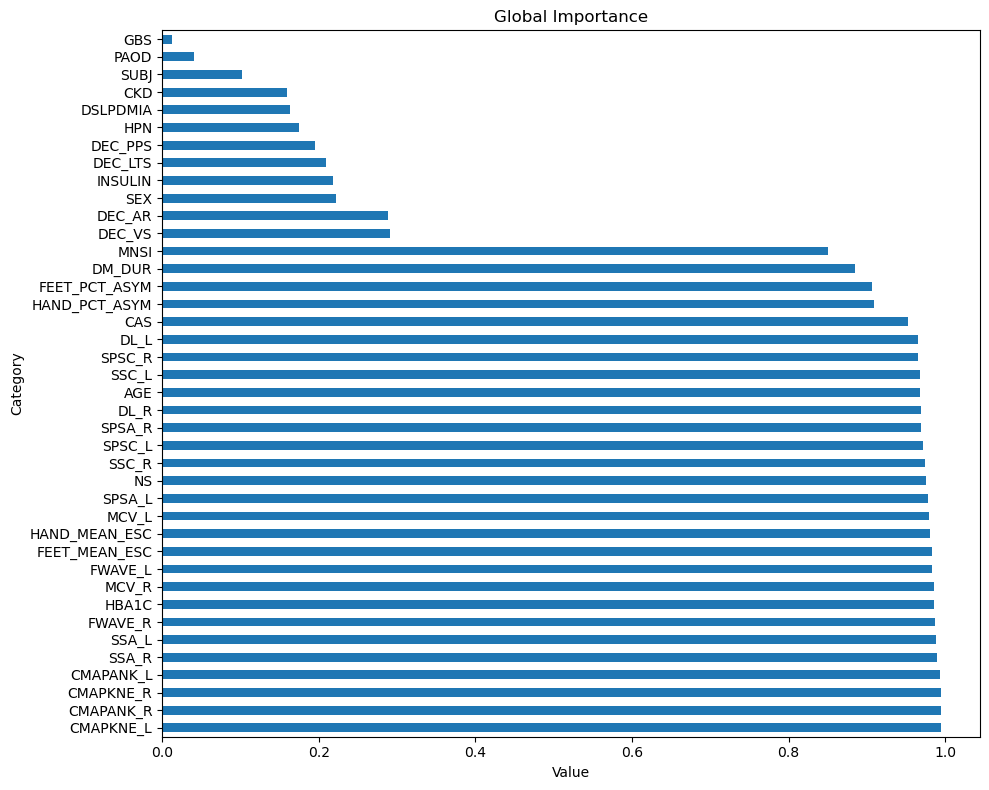

In [42]:
s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots(figsize=(10, 8))
s.plot.barh(ax=ax)
ax.set_title("Global Importance")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_global.png')
plt.show()


In [44]:
df_imp.to_csv(r'outputs\counterfactuals\rf_global.csv')

#### Load Global Feature Importance from File

In [92]:
df_imp = pd.read_csv(r'outputs\counterfactuals\rf_global.csv')
df_imp

,Unnamed: 0,CMAPKNE_L,CMAPANK_R,CMAPKNE_R,CMAPANK_L,SSA_R,SSA_L,FWAVE_R,HBA1C,MCV_R,FWAVE_L,FEET_MEAN_ESC,HAND_MEAN_ESC,MCV_L,SPSA_L,NS,SSC_R,SPSC_L,SPSA_R,DL_R,AGE,SSC_L,SPSC_R,DL_L,CAS,HAND_PCT_ASYM,FEET_PCT_ASYM,DM_DUR,MNSI,DEC_VS,DEC_AR,SEX,INSULIN,DEC_LTS,DEC_PPS,HPN,DSLPDMIA,CKD,SUBJ,PAOD,GBS
0,0,0.995,0.995,0.995,0.993,0.99,0.988,0.987,0.985,0.985,0.984,0.983,0.981,0.98,0.978,0.975,0.974,0.971,0.969,0.969,0.967,0.967,0.966,0.965,0.952,0.909,0.906,0.884,0.85,0.291,0.289,0.222,0.218,0.209,0.195,0.175,0.163,0.16,0.101,0.041,0.013


In [ ]:
blue_hex_colors = [
    '#ADD8E6', # Light Blue
    '#87CEEB', # Sky Blue
    '#6495ED', # Cornflower Blue
    '#4682B4', # Steel Blue
    '#1E90FF', # Dodger Blue
    '#0000CD', # Medium Blue
    '#00008B', # Dark Blue
    '#000080'  # Navy
]

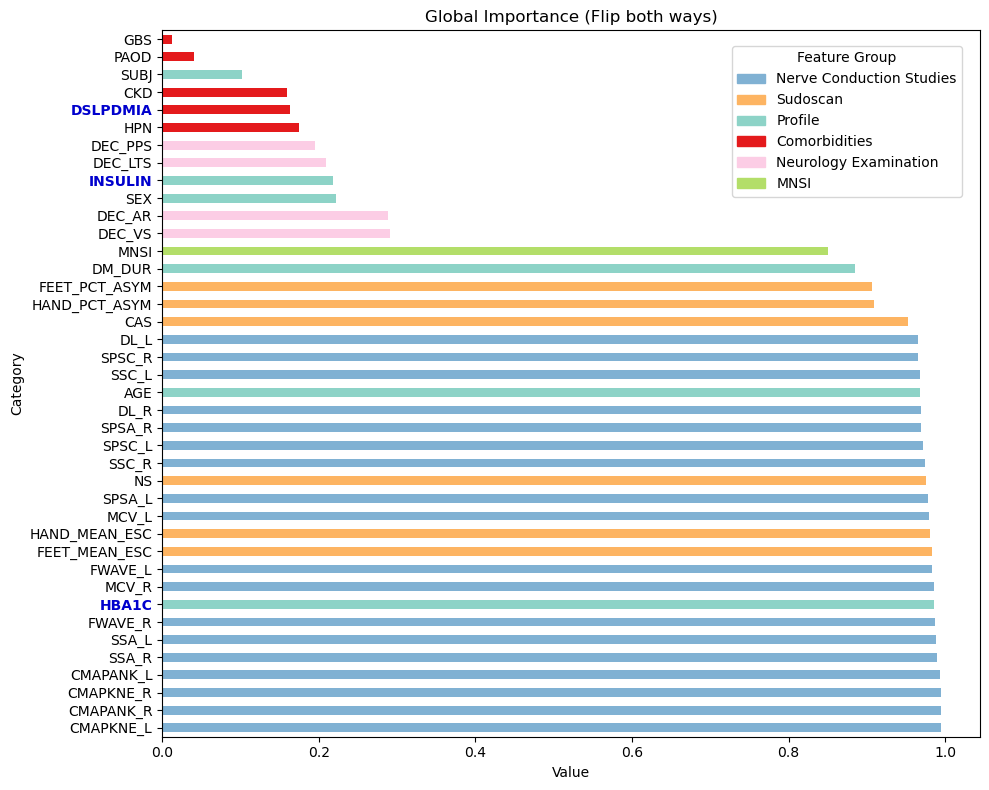

In [110]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
ACTIONABLE_FEATURES = {'HBA1C', 'DSLPDMIA', 'INSULIN'} 

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in ACTIONABLE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Flip both ways)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
#plt.savefig('outputs/figures/rf_cf_global.png')
plt.show()



#### Local Feature Importance

In [78]:
pid = 0
query_instance = X[pid:pid+1]
e1 = exp.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")    
# e1.visualize_as_dataframe(show_only_changes=True) 

100%|██████████| 1/1 [00:05<00:00,  5.95s/it]


In [79]:
imp = exp.local_feature_importance(query_instance, cf_examples_list=e1.cf_examples_list)
df_imp = pd.DataFrame(imp.local_importance)
df_imp

,AGE,DM_DUR,HBA1C,MNSI,SPSA_L,SSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FEET_MEAN_ESC,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,SSC_L,SPSC_L,DL_L,CMAPANK_L,CMAPKNE_L,SSA_R,SPSA_R,SPSC_R,CAS,SEX,DEC_LTS,DEC_AR,FWAVE_R,SSA_L,INSULIN,FWAVE_L,FEET_PCT_ASYM,MCV_L,SUBJ,DEC_VS,HPN,GBS,DEC_PPS,PAOD,DSLPDMIA,CKD
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.8,0.8,0.8,0.8,0.6,0.5,0.5,0.5,0.4,0.2,0.2,0.1,0.1,0.1,0.0,0.0,0.0


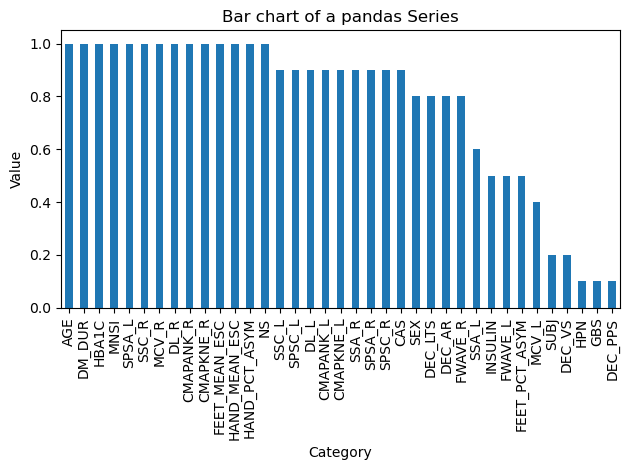

In [80]:
import matplotlib.pyplot as plt

s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots()
s.plot.bar(ax=ax)
ax.set_title("Bar chart of a pandas Series")
ax.set_xlabel("Category")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

#### Necessity and Sufficiency of Instances

In [91]:
import pandas as pd

def check_necessity_sufficiency(dice_exp, instance, all_features, desired_class="opposite", 
                                n_cf=10, seeds=[0,1,2,3,4], return_df=True):
    """
    Check necessity and sufficiency of features using DiCE.
    
    Parameters
    ----------
    dice_exp : dice_ml.Dice object
        Fitted DiCE explanation object.
    instance : dict or pd.DataFrame row
        The input instance to analyze.
    all_features : list
        List of feature names in the dataset.
    desired_class : str
        Target class for counterfactuals ("opposite" by default).
    n_cf : int
        Number of counterfactuals to request (for reliability).
    seeds : list
        Random seeds to try for sufficiency tests.
    return_df : bool
        If True, return pandas DataFrame. If False, return dict.
    
    Returns
    -------
    results : pd.DataFrame or dict
        Necessity and sufficiency results for each feature.
    """
    
    results = {}

    for f in tqdm(all_features):
        print(f)
        results[f] = {"necessary": False, "sufficient": False}

        # --- Necessity: vary only this feature ---
        cf_nec = dice_exp.generate_counterfactuals(
            instance,
            total_CFs=1,
            desired_class=desired_class,
            features_to_vary=[f]
        )
        if len(cf_nec.cf_examples_list[0].final_cfs_df) > 0:
            results[f]["necessary"] = True

        # --- Sufficiency: vary all features except this one ---
        features_without_f = [feat for feat in all_features if feat != f]
        
        found_cf = False
        for seed in seeds:
            cf_suff = dice_exp.generate_counterfactuals(
                instance,
                total_CFs=n_cf,
                desired_class=desired_class,
                features_to_vary=features_without_f,
                random_seed=seed
            )
            if len(cf_suff.cf_examples_list[0].final_cfs_df) > 0:
                found_cf = True
                break   # one valid CF is enough to say "not sufficient"
        
        if not found_cf:
            results[f]["sufficient"] = True

    if return_df:
        df_results = pd.DataFrame.from_dict(results, orient="index")
        df_results.index.name = "feature"
        return df_results
    else:
        return results


In [92]:
pid = 0
query_instance = X[pid:pid+1]
all_features = list(X.columns)[:3]

In [ ]:
df_necsuf = check_necessity_sufficiency(
    exp, 
    query_instance, 
    all_features, 
    desired_class="opposite",
    n_cf=10,           # more CFs per trial
    seeds=[0,1,2,3,4][:1]  # multiple seeds
)
df_necsuf

### Progressive CF (Flip Negative to Positive)

In [119]:
X[y==0].shape

(60, 40)

In [122]:
cobj = exp.global_feature_importance(X[y==0], total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

100%|██████████| 60/60 [00:57<00:00,  1.04it/s]


{'SSA_L': 1.0, 'CMAPANK_L': 1.0, 'CMAPKNE_L': 1.0, 'CMAPANK_R': 1.0, 'CMAPKNE_R': 1.0, 'SSA_R': 0.9983333333333333, 'FWAVE_R': 0.9983333333333333, 'MCV_R': 0.9933333333333333, 'FEET_MEAN_ESC': 0.9933333333333333, 'SSC_R': 0.99, 'SPSA_L': 0.9883333333333333, 'SPSA_R': 0.985, 'SSC_L': 0.9833333333333333, 'MCV_L': 0.9833333333333333, 'HAND_MEAN_ESC': 0.98, 'FWAVE_L': 0.9783333333333334, 'NS': 0.9766666666666667, 'SPSC_R': 0.9733333333333334, 'SPSC_L': 0.97, 'HBA1C': 0.9683333333333334, 'AGE': 0.965, 'DL_L': 0.965, 'DL_R': 0.9583333333333334, 'CAS': 0.9433333333333334, 'HAND_PCT_ASYM': 0.9033333333333333, 'FEET_PCT_ASYM': 0.845, 'MNSI': 0.8116666666666666, 'DM_DUR': 0.8016666666666666, 'SEX': 0.18666666666666668, 'INSULIN': 0.12833333333333333, 'DEC_LTS': 0.11, 'DSLPDMIA': 0.10166666666666667, 'DEC_PPS': 0.09666666666666666, 'HPN': 0.09333333333333334, 'CKD': 0.09333333333333334, 'DEC_VS': 0.09, 'SUBJ': 0.08333333333333333, 'DEC_AR': 0.06666666666666667, 'PAOD': 0.018333333333333333, 'GBS'

In [123]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

,SSA_L,CMAPANK_L,CMAPKNE_L,CMAPANK_R,CMAPKNE_R,SSA_R,FWAVE_R,MCV_R,FEET_MEAN_ESC,SSC_R,SPSA_L,SPSA_R,SSC_L,MCV_L,HAND_MEAN_ESC,FWAVE_L,NS,SPSC_R,SPSC_L,HBA1C,AGE,DL_L,DL_R,CAS,HAND_PCT_ASYM,FEET_PCT_ASYM,MNSI,DM_DUR,SEX,INSULIN,DEC_LTS,DSLPDMIA,DEC_PPS,HPN,CKD,DEC_VS,SUBJ,DEC_AR,PAOD,GBS
0,1.0,1.0,1.0,1.0,1.0,0.998,0.998,0.993,0.993,0.99,0.988,0.985,0.983,0.983,0.98,0.978,0.977,0.973,0.97,0.968,0.965,0.965,0.958,0.943,0.903,0.845,0.812,0.802,0.187,0.128,0.11,0.102,0.097,0.093,0.093,0.09,0.083,0.067,0.018,0.015


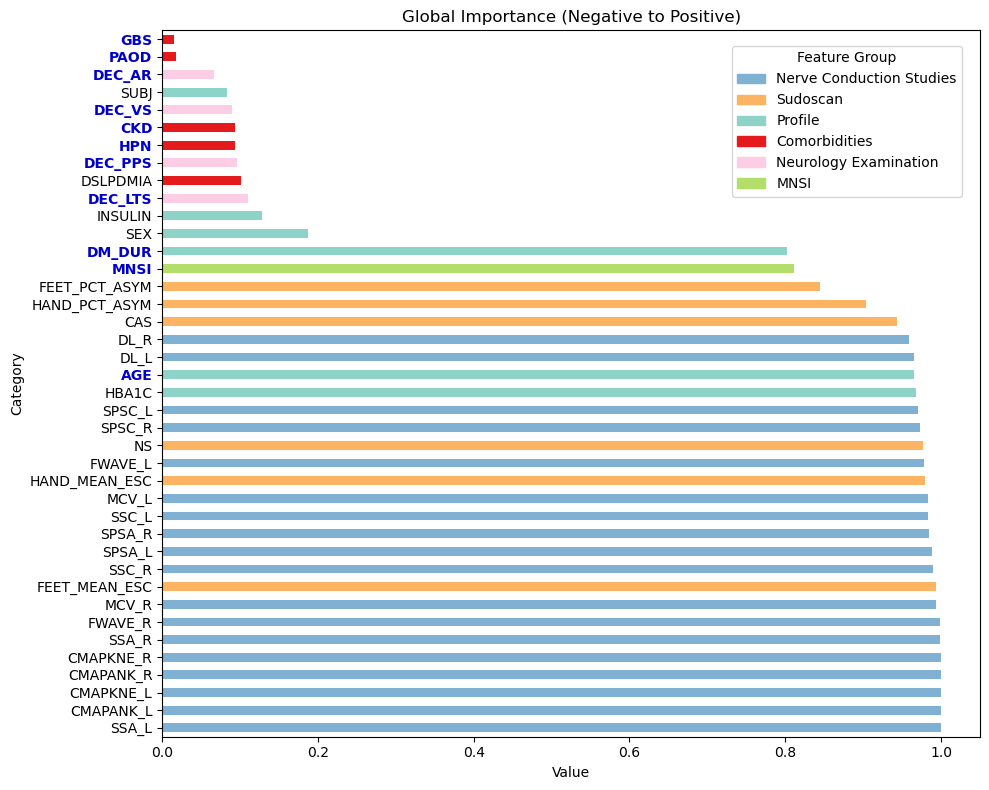

In [126]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
PROGRESSIVE_FEATURES = {'DM_DUR', 'CKD', 'PAOD', 'HPN', 'GBS', 'AGE', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI'}

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in PROGRESSIVE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Negative to Positive)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_proressive_global.png')
plt.show()

### Hypothetical CF (Flip Positive to Negative)

In [127]:
X[y==1].shape

(130, 40)

In [128]:
cobj = exp.global_feature_importance(X[y==1], total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

  0%|          | 0/130 [00:00<?, ?it/s]

100%|██████████| 130/130 [37:26<00:00, 17.28s/it]


{'CMAPANK_R': 0.9992242048099301, 'CMAPANK_L': 0.9984484096198604, 'CMAPKNE_L': 0.9984484096198604, 'CMAPKNE_R': 0.9984484096198604, 'SSA_R': 0.9937936384794415, 'HBA1C': 0.9906904577191621, 'MCV_L': 0.9891388673390225, 'MCV_R': 0.9891388673390225, 'FWAVE_L': 0.9875872769588828, 'FWAVE_R': 0.9875872769588828, 'SPSA_L': 0.9821567106283942, 'FEET_MEAN_ESC': 0.9821567106283942, 'SSA_L': 0.9813809154383243, 'DL_R': 0.9759503491078355, 'HAND_MEAN_ESC': 0.9759503491078355, 'NS': 0.9728471683475562, 'AGE': 0.9720713731574864, 'SPSC_L': 0.9712955779674166, 'DL_L': 0.9705197827773467, 'SSC_R': 0.9681923972071373, 'SPSC_R': 0.9658650116369278, 'SSC_L': 0.9650892164468581, 'SPSA_R': 0.9635376260667183, 'CAS': 0.9550038789759504, 'FEET_PCT_ASYM': 0.9278510473235065, 'HAND_PCT_ASYM': 0.9193173002327386, 'DM_DUR': 0.9138867339022498, 'MNSI': 0.861132660977502, 'DEC_VS': 0.3832428238944919, 'DEC_AR': 0.365399534522886, 'INSULIN': 0.25368502715283164, 'DEC_LTS': 0.2529092319627618, 'DEC_PPS': 0.238944

In [ ]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

,SSA_L,CMAPANK_L,CMAPKNE_L,CMAPANK_R,CMAPKNE_R,SSA_R,FWAVE_R,MCV_R,FEET_MEAN_ESC,SSC_R,SPSA_L,SPSA_R,SSC_L,MCV_L,HAND_MEAN_ESC,FWAVE_L,NS,SPSC_R,SPSC_L,HBA1C,AGE,DL_L,DL_R,CAS,HAND_PCT_ASYM,FEET_PCT_ASYM,MNSI,DM_DUR,SEX,INSULIN,DEC_LTS,DSLPDMIA,DEC_PPS,HPN,CKD,DEC_VS,SUBJ,DEC_AR,PAOD,GBS
0,1.0,1.0,1.0,1.0,1.0,0.998,0.998,0.993,0.993,0.99,0.988,0.985,0.983,0.983,0.98,0.978,0.977,0.973,0.97,0.968,0.965,0.965,0.958,0.943,0.903,0.845,0.812,0.802,0.187,0.128,0.11,0.102,0.097,0.093,0.093,0.09,0.083,0.067,0.018,0.015


In [ ]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
PROGRESSIVE_FEATURES = {'DM_DUR', 'CKD', 'PAOD', 'HPN', 'GBS', 'AGE', 
                        'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI'}

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in PROGRESSIVE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Negative to Positive)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_proressive_global.png')
plt.show()

## Local Counterfactual Analysis

#### Preparation

In [26]:
X.shape, y.shape

((190, 40), (190,))

In [27]:
dfXy = pd.concat([X, y], axis=1)
dfXy.shape

(190, 41)

In [28]:
d = dice_ml.Data(dataframe=dfXy, continuous_features=dfXy.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=optimized_model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")

#### Generate 3 Sample CFs for Patient 0

In [29]:
pid = 0
query_instance = X[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 


generating counterfactuals for the random_forest model


100%|██████████| 1/1 [00:00<00:00,  2.09it/s]

Query instance (original outcome : 1)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,64.0,1.0,7.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,25.0,-,1.0,0.0,11.0,-,-,-,-,-,0.0,-,-,-,5.0,12.1,47.5,6.8,42.0,40.8,3.5,13.71,7.21,52.6,13.3,43.2,6.0,42.7,40.3,3.8,11.1,6.93,52.7,37.0,5.0,46.0,14.0,76.0,7.0,0.0
0,0.0,59.0,-,4.0,0.0,10.5,-,-,-,-,-,-,-,-,-,3.0,10.1,51.5,4.4,59.6,47.4,3.25,16.2,10.13,45.1,13.1,54.5,5.9,52.6,47.6,3.6,17.12,10.07,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0
0,-,48.0,-,10.0,-,10.9,1.0,-,-,-,-,-,-,0.0,0.0,12.0,10.8,46.0,6.4,45.2,40.5,4.15,9.81,8.71,44.1,11.8,45.3,10.5,45.6,49.3,5.7,11.21,7.21,43.2,30.0,-,28.0,3.0,0.0,29.0,0.0


In [ ]:
optimized_model.fit(X_train, y_train)
y_pred = optimized_model.predict(X_val)
y_proba = best_model.predict_proba(X_val)[:, 1]


### Get logits

In [30]:
# optimized_model.fit(X_train, y_train) # no longer needed
y_pred = optimized_model.predict(X_val)
y_proba = optimized_model.predict_proba(X_val)[:, 1]

In [32]:
y_pred

array([1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0])

In [31]:
y_proba

array([1.   , 0.965, 0.341, 0.037, 0.897, 0.069, 0.795, 1.   , 0.074,
       0.691, 0.952, 0.969, 0.971, 0.883, 0.609, 0.985, 0.984, 0.976,
       0.037, 0.472, 0.757, 0.959, 0.76 , 0.99 , 0.984, 0.117, 0.984,
       0.775, 0.977, 0.033, 0.069, 0.99 , 0.952, 1.   , 0.017, 0.175,
       0.492, 0.008, 1.   , 0.483, 0.729, 0.901, 0.837, 0.951, 0.962,
       0.932, 0.163, 0.299])

In [39]:
y_val

165    1
2      1
182    0
21     0
10     1
70     0
18     1
83     1
81     0
178    0
145    1
16     1
108    1
148    1
127    1
173    1
150    1
48     1
72     0
40     1
151    1
60     1
8      1
76     1
58     1
129    0
103    1
171    1
189    1
147    0
7      0
91     1
0      1
64     1
1      0
153    0
96     1
159    0
24     1
42     0
54     1
118    1
82     1
140    1
15     1
114    1
135    0
80     0
Name: Confirmed_Binary_DPN, dtype: int32

### Misclassified Local Counterfactuals

In [37]:
y_pred==np.array(y_val)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [46]:
misclassified_indices = np.where(y_pred != np.array(y_val))[0]
misclassified_indices = misclassified_indices.tolist()
misclassified_indices

[9, 19, 36]

In [51]:
y_val.iloc[misclassified_indices]

178    0
40     1
96     1
Name: Confirmed_Binary_DPN, dtype: int32

In [96]:
y_proba[9]

0.6909087204719281

In [52]:
y_pred[misclassified_indices]

array([1, 0, 0])

In [62]:
pid=96
X[pid:pid+1]

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
96,0,51.0,1,3.0,1.0,12.4,1,0,1,0,0,0,1,1,0,6.0,13.74,53.0,10.39,48.0,42.6,3.3,6.72,4.61,49.9,14.63,59.6,8.24,46.1,42.0,3.2,10.01,6.42,49.0,31.0,9.0,31.0,9.0,73.0,23.0


#### Patient 41

In [ ]:
pid = 40 # dataframe is zero-indexed
query_instance = X[pid:pid+1]
print(f"Generating counterfactuals for Patient {pid+1}... ")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=30, desired_class="opposite")
#e1.visualize_as_dataframe(show_only_changes=True) 

### Borderline Local Counterfactuals

In [103]:
margin = 0.05
borderline_indices = np.where((y_proba>(0.5-margin)) & (y_proba<(0.5+margin)))
borderline_indices

(array([19, 36, 39], dtype=int64),)

In [104]:
y_val.iloc[borderline_indices]

40    1
96    1
42    0
Name: Confirmed_Binary_DPN, dtype: int32

In [105]:
y_pred[borderline_indices]

array([0, 0, 0])

#### Patient 41

In [ ]:
pid = 40 # dataframe is zero-indexed
query_instance = X[pid:pid+1]
print(f"Generating counterfactuals for Patient {pid+1}... ")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=30, desired_class="opposite")
#e1.visualize_as_dataframe(show_only_changes=True) 

 -----

## Raze Code

### DICT OF INITIAL MODELS

Logistic Regression Scaling

In [ ]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

In [ ]:
initial_models = {
    "dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression
}

### RUNNING EACH MODEL

In [ ]:
verbosity = 0    
initial_model_runs = get_metrics(initial_models)
#pprint(initial_model_runs)
pd.DataFrame(initial_model_runs)

### BINARY GRID SEARCH CV

DICT OF ESTIMATORS

In [ ]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

In [ ]:
estimators = {
    #"dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression
}

LOADING PARAMETER GRIDS FROM JSON

In [ ]:
# LOADING JSON FILE STORING PARAMETER CONFIGURATIONS
with open('model_configs/param_grids/binary_param_grids.json', 'r') as file:
    param_grids = json.load(file)

In [ ]:
param_grids

### RUNNING BINARY GRID SEARCH CV ON EACH ESTIMATOR

In [ ]:
optimized_params = {}

start_time = time.time()

# CONDUCTING GRID_SEARCH_CV ON THE BINARY CLASSIFICATION MODELS
for estimator_name, estimator in estimators.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(estimator_name)
    
    params = grid_search_cv_binary(
        estimator,
        param_grids.get(estimator_name, {}),
        (X_train_temp, y_train_temp),
        scoring='youden_index',
        verbosity=verbosity,
        cv_splits=5
    )

    print("Optimized parameters for {}: {}".format(estimator_name, params))

    optimized_params[estimator_name] = params.best_params_

end_time = time.time()

pprint(optimized_params)

print(f"Grid Search finished in {end_time - start_time} seconds")

In [ ]:
optimized_params['xgb']

### DICT OF OPTIMIZED MODELS

Generated parameter set is inputted into the classifiers as kwargs

In [ ]:
#.
def strip_classifier_prefix(params):
    return {k.replace('classifier__', ''): v for k, v in params.items()}
logreg_params = strip_classifier_prefix(optimized_params["logistic_regression"])
#.

logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    #. ('classifier', LogisticRegression(**optimized_params["logistic_regression"]))
    ('classifier', LogisticRegression(**logreg_params)) #.
])

In [ ]:
optimized_models = {
    "xgb": xgb.XGBClassifier(**optimized_params["xgb"]),
    "random_forest": RandomForestClassifier(**optimized_params["random_forest"]),
    "decision_tree": DecisionTreeClassifier(**optimized_params["decision_tree"]),
    "logistic_regression": logistic_regression
}

In [ ]:
best_youden = (None, 0)

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    stats = EDA.binary_classification_metrics(
        confusion_matrix(
            y_val_temp,
            model.fit(X_train_temp, y_train_temp).predict(X_val_temp)
        ),
        labels=D.binary_classes_labels, verbosity=verbosity)

    print(f"Statistics for optimized {model_name} model")
    best_youden = (model_name, stats['youden_index']) if stats['youden_index'] > best_youden[1] else best_youden
    pprint(stats)
    
print(f"The best model is: {best_youden[0]} with a youden_index of {best_youden[1]}")

In [ ]:
optimized_model_runs = get_metrics(optimized_models)
pprint(optimized_model_runs)

In [ ]:
from utils.plotting_helper import display_binary_model_metrics
pd.DataFrame(optimized_model_runs)
#display_binary_model_metrics(optimized_model_runs)

In [ ]:
## Save optimized parameters, models, and statistics

import joblib
joblib.dump(optimized_params, "optimized_models\optimized_models_params.pkl")
joblib.dump(optimized_models, "optimized_models\optimized_models.pkl")
joblib.dump(optimized_model_runs, "optimized_models\optimized_models_metrics.pkl")


### Generating Counterfactuals for Each Model

In [ ]:
cf_explainers = {}

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
    y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)

    df_temp = pd.concat([X_temp, y_temp], axis=1)

    model.fit(X_train_temp, y_train_temp)
    
    d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
    m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")
    
    exp = dice_ml.Dice(d, m, method="genetic")
    
    print(f"generating counterfactuals for the {model_name} model")
    
    e1 = exp.generate_counterfactuals(
        X_val_temp, total_CFs=3, desired_class="opposite")
    
    cf_explainers[model_name] = e1

In [ ]:
# Define a simple distance function (Euclidean distance)
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

dist = euclidean_distance

constraints = [
    {'feature': 0, 'type': 'unchanged', 'action': 'increase'},
    {'feature': 1, 'type': 'unchanged', 'action': 'increase'}
]

In [ ]:
cf_explainers[best_youden[0]].visualize_as_dataframe(show_only_changes=True)

In [ ]:
print(type(cf_explainers[best_youden[0]].cf_examples_list[0]))

print(vars(cf_explainers[best_youden[0]].cf_examples_list[0]))


In [ ]:
df_merged = pd.concat([X_val, y_val], axis=1)
df_merged

data = pd.concat([X, y], axis=1)

In [ ]:
evaluator = CEval(df_merged, "Confirmed_Binary_DPN", df, optimized_models[best_youden[0]].fit(X_train, y_train), 3, cdist='euclidean', constraints=constraints)

In [ ]:
cf_explainers[best_youden[0]].cf_examples_list[0].final_cfs_df

In [ ]:
print(vars(cf_explainers[best_youden[0]].cf_examples_list[0]))

In [ ]:
cf_list = cf_explainers[best_youden[0]].cf_examples_list[0]
print(type(cf_list))
print(cf_list)

In [ ]:
cf_df = pd.DataFrame([cf_list])
cf_df

In [ ]:
evaluator.add_explainer("DiCE_explanation", cf_df, exp_type="generated-cf", mode='1toN')

In [ ]:
display(evaluator.comparison_table)

In [ ]:
# Assuming X_val, y_val, and optimized_models are already defined and populated.
# Also assuming D.binary_class_label is 'Confirmed_Binary_DPN' and
# D.multi_classes_labels is ['Negative', 'Possible', 'Probable', 'Confirmed']

# --- Example Usage ---

best_binary_model = optimized_models[best_youden[0]].fit(X_train, y_train)

X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(best_youden[0])

# For Binary Classification Model (e.g., XGBoost)
print(f"\n--- Plotting ROC for the Best Binary Model {best_youden[0]} ---")
# Make sure you are passing the *trained pipeline* if you are using one
# For this example, I'm assuming optimized_models["xgb"] is the fitted pipeline
EDA.plot_roc_binary_from_model(
    model=best_binary_model,
    X_val=X_val_temp,
    y_val=y_val_temp, # This should be your binary y_val (0 or 1)
    class_label="Confirmed_Binary_DPN"
)

In [ ]:
import shap

# --- Automated SHAP Analysis ---
for model_name, model in optimized_models.items():
    print(f"🚀 Analyzing SHAP values for: {model_name}")

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    model.fit(X_train_temp, y_train_temp)

    # Define a simple predict function for the current model
    # This closure ensures 'model' refers to the correct model in each iteration
    def current_model_predict(X):
        # For classifiers, .predict_proba is often preferred for SHAP for better interpretability
        # especially for multi-class, but .predict is also valid.
        # We'll use .predict here as per your original request, but it's good to note.
        return model.predict(X)

    # Use a masker: your input DataFrame
    masker = shap.maskers.Independent(X_val_temp)

    # Create explainer with custom predict function
    # Specify the masker for consistency
    explainer = shap.Explainer(current_model_predict, masker=masker)

    # Compute SHAP values
    shap_values = explainer(X_val_temp)

    # Plot the summary plot for the current model
    # show=False prevents immediate display, allowing title to be set
    shap.summary_plot(shap_values, X_val_temp, show=False, plot_type="bar")
    plt.title(f"SHAP Summary Plot for {model_name.replace('_', ' ').title()}")
    plt.tight_layout() # Adjust layout to prevent title overlap
    plt.show() # Display the plot for the current model
    print("-" * 50) # Separator for clarity


In [ ]:
from utils.eval import DiceEvaluator

# models
best_model = optimized_models[best_youden[0]].fit(X_train, y_train)
cf_explainer = cf_explainers[best_youden[0]]

# Instantiate the evaluator
evaluator = DiceEvaluator(cf_explainer, df)

evaluator.get_stats(verbosity=0)

# Tony

In [24]:
import joblib
loaded_optimized_params = joblib.load("outputs\optimized_models_params.pkl")
loaded_optimized_models = joblib.load("outputs\optimized_models.pkl")
loaded_optimized_model_runs = joblib.load("outputs\optimized_models_metrics.pkl")
loaded_optimized_model_runs

{'xgb': {'sensitivity': 0.9393939393939394,
  'specificity': 0.7333333333333333,
  'youden_index': 0.6727272727272728,
  'accuracy': 0.875},
 'random_forest': {'sensitivity': 0.9393939393939394,
  'specificity': 0.8666666666666667,
  'youden_index': 0.8060606060606061,
  'accuracy': 0.9166666666666666},
 'decision_tree': {'sensitivity': 0.8787878787878788,
  'specificity': 0.8,
  'youden_index': 0.6787878787878787,
  'accuracy': 0.8541666666666666},
 'logistic_regression': {'sensitivity': 0.9090909090909091,
  'specificity': 0.8,
  'youden_index': 0.709090909090909,
  'accuracy': 0.875}}

In [25]:
model_name = 'random_forest'
model = loaded_optimized_models[model_name]

In [ ]:
X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)
X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)
df_temp = pd.concat([X_temp, y_temp], axis=1)
model.fit(X_train_temp, y_train_temp)

In [ ]:
d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")
print(f"generating counterfactuals for the {model_name} model")

In [ ]:
pid = 0
query_instance = X_temp[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=10, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 
